# Southwest Airlines: Financial Performance Analysis (1995–2025)


## 1. Introduction

This project analyses the financial performance of Southwest Airlines Co. using quarterly financial data from the U.S. Department of Transportation. The analysis focuses on operating revenue, operating expenses, operating profit, and operating profit margin over the period from 1995 to 2025. The aim is to identify long-term trends in the airline's financial performance, examine periods of strong and weak profitability, and investigate the relationship between revenue growth and expense growth. The analysis uses Python and pandas to clean, process, and analyse the data before presenting the results through charts and key findings.

## 2. Data Loading

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('export.csv')

## 3. Data Cleaning

In [5]:
df.shape

(213452, 13)

In [6]:
df.columns

Index(['CarProcessGrp', 'Period_Type', 'Year', 'Quarter', 'Group_Sort',
       'Group_Name', 'Airline_Id', 'UniqueCarrier', 'UniqueCarrierName',
       'Item_Id', 'Item_Name', 'Item_Value', 'pk'],
      dtype='object')

In [7]:
df['Item_Name'].unique()

array(['Net Income (Loss)', 'Ton Load Factor (All Svc.)',
       'Operating Revenues', 'Operating Expense per RTM',
       'Operating Profit (Loss) per RTM', 'Operating Expense per ATM',
       'Passenger Revenue per RPM',
       'Operating Revenues to Total Investment', 'Times Interest Earned',
       'Current Assets to Current Liabilities',
       'No. of Days Cash Coverage of Cash Exp.',
       'Operating Profit (Loss) to Operating Revenue',
       'Net Income to Stockholders Equity', 'Operating Expenses',
       'Corporate Return on Investment', 'Debt to Total Investment',
       'Passenger Load Factor (Sch. Svc.)',
       'Employment, Total Weighted Avg CY',
       "Overall RTM's per Employee (000)", 'Operating Profit (Loss)',
       'Total Debt (in Millions $)', 'RPMs - Scheduled Rev. Svc.',
       'ASMs - Scheduled Rev. Svc.', 'Overall RTMs (All Svc.)',
       'Overall ATMs (All Svc.)', 'Operating Revenue per RTM', 'Actual',
       'Breakeven', 'RTMs - Scheduled Svc.', 'ATMs - S

In [8]:
financialdf = df[df['Item_Name'].isin(['Operating Revenues','Operating Expenses','Operating Profit (Loss)','Operating Profit (Loss) to Operating Revenue'])]

In [9]:
financialdf.shape

(36008, 13)

In [10]:
len(financialdf['UniqueCarrier'].unique())

71

In [11]:
financialdf['UniqueCarrierName'].unique()

array([nan, 'Aloha Airlines Inc.', 'Horizon Air',
       'Hawaiian Airlines Inc.', 'Carnival Air Lines Inc.',
       'USAir Shuttle', 'Continental Micronesia',
       'Air Wisconsin Airlines Corp', 'Western Pacific Airlines',
       'Tower Air Inc.', 'World Airways Inc.', 'Kiwi International',
       'Trans States Airlines', 'American Trans Air Inc.',
       'Midwest Express Airlines', 'Atlantic Southeast Airlines',
       'ExpressJet Airlines Inc.', 'Mesa Airlines Inc.',
       'Business Express', 'American Eagle Airlines Inc.',
       'Executive Airlines', 'Spirit Air Lines', 'Sun Country Airlines',
       'Frontier Airlines Inc.', 'AirTran Airways Corporation',
       'Northwest Airlines Inc.', 'Southwest Airlines Co.',
       'Continental Air Lines Inc.', 'Delta Air Lines Inc.',
       'American Airlines Inc.', 'United Parcel Service',
       'Alaska Airlines Inc.', 'United Air Lines Inc.',
       'America West Airlines Inc.', 'Federal Express Corporation',
       'Trans World Airl

## 4. Selecting Southwest Airlines


In [14]:
southwestdf = financialdf[financialdf['UniqueCarrierName'] == 'Southwest Airlines Co.']

In [15]:
southwestdf.shape

(716, 13)

In [17]:
southwestdf['Quarter'].unique()

array([3, 4, 1, 2])

In [18]:
southwestdf['Item_Value'].isna().sum()

np.int64(0)

In [19]:
southwestdf[southwestdf['Item_Name'] == 'Operating Revenues']['Item_Value'].sum()

'765,159,000.0000748,840,000.0000772,821,000.0000910,606,000.0000891,792,000.0000832,142,000.0000887,205,000.0000956,907,000.0000997,255,000.0000975,630,000.0000942,668,000.00001,078,856,000.00001,094,845,000.00001,047,671,000.00001,075,587,000.00001,220,448,000.00001,235,180,000.00001,204,433,000.00001,242,662,000.00001,460,691,000.00001,478,848,000.00001,467,420,000.00005,928,700,000.00001,428,632,000.00001,553,800,000.00001,335,140,000.00001,237,663,000.00001,257,258,000.00001,472,812,000.00001,391,206,000.00001,400,553,000.00001,351,261,000.00001,515,087,000.00001,553,404,000.00001,516,944,000.00001,483,986,000.00001,716,248,000.00001,674,419,000.00001,654,967,000.00001,663,506,000.00001,944,489,000.00001,988,625,000.00001,987,217,000.00002,019,452,000.00002,449,027,000.00002,342,058,000.00002,275,762,000.00002,197,557,000.00002,583,169,000.00002,588,018,000.00003,075,874,993.000013,328,216,618.000013,575,721,093.00003,125,992,764.00003,562,540,138.00003,563,808,723.00003,323,379,4

In [20]:
southwestdf['Period_Type'].unique()

array(['Q', 'A'], dtype=object)

In [96]:
southwestq = southwestdf[southwestdf['Period_Type'] =='Q'].copy()

In [22]:
southwestq.shape

(488, 13)

In [23]:
southwestq[['Year', 'Quarter']].drop_duplicates().shape[0]

122

In [24]:
all_quarters = pd.MultiIndex.from_product(
    [range(1995, 2026), [1, 2, 3, 4]],
    names=['Year', 'Quarter']
)

existing_quarters = pd.MultiIndex.from_frame(
    southwestq[['Year', 'Quarter']].drop_duplicates()
)

all_quarters.difference(existing_quarters)

MultiIndex([(1995, 1),
            (1995, 2)],
           names=['Year', 'Quarter'])

In [97]:
southwestq['Item_Value'] = (
    southwestq['Item_Value']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

## 5. Annual Revenue Analysis

In [27]:
southwestq[(southwestq['Item_Name'] == 'Operating Revenues') & (southwestq['Year'] == 1995)]['Item_Value'].sum()

np.float64(1513999000.0)

In [28]:
 rev = southwestq[southwestq['Item_Name']=='Operating Revenues'].groupby('Year')['Item_Value'].sum()

In [29]:
import matplotlib.pyplot as plt


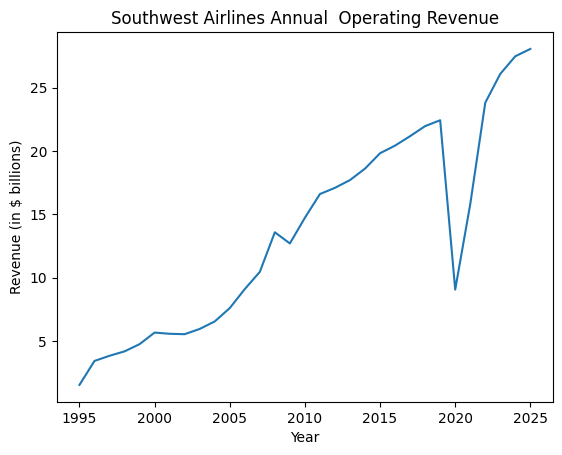

In [87]:
rev_bill = rev/1e9
plt.plot(rev_bill.index, rev_bill.values)
plt.title('Southwest Airlines Annual  Operating Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue (in $ billions)')
plt.show()

## 6. Profitability Analysis

In [31]:
profit = southwestq[southwestq['Item_Name']=='Operating Profit (Loss)'].groupby('Year')['Item_Value'].sum()

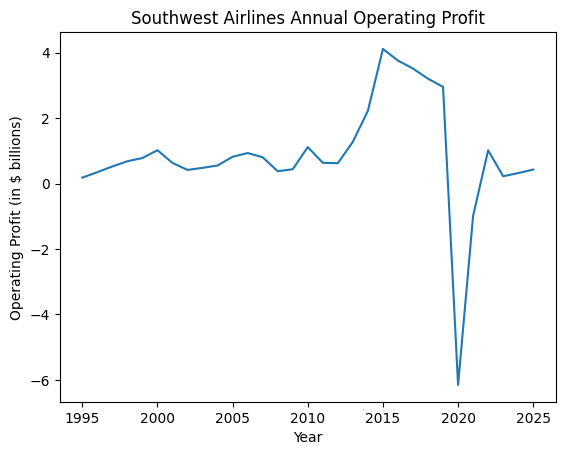

In [88]:
profit_bill = profit / 1e9

plt.plot(profit_bill.index, profit_bill.values)

plt.title('Southwest Airlines Annual Operating Profit')
plt.xlabel('Year')
plt.ylabel('Operating Profit (in $ billions)')

plt.show()

In [32]:
margin = profit/rev * 100

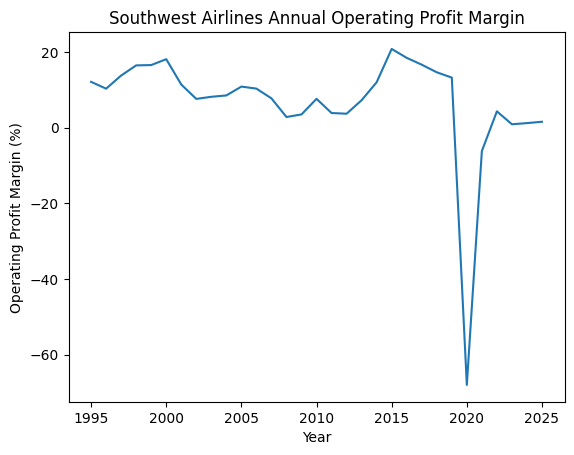

In [89]:
plt.plot(margin.index,margin.values)
plt.title('Southwest Airlines Annual Operating Profit Margin')
plt.xlabel('Year')
plt.ylabel('Operating Profit Margin (%)')
plt.show()

## 7. Revenue vs Expense Growth

In [49]:
yoyr = 100 * (rev.pct_change())

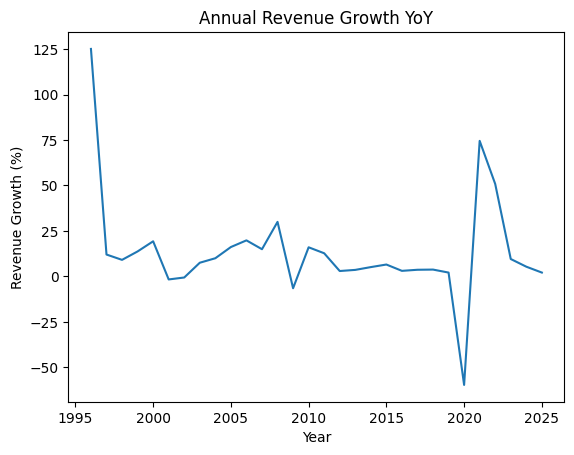

In [90]:
plt.plot(yoyr.index, yoyr.values)

plt.title('Annual Revenue Growth YoY')
plt.xlabel('Year')
plt.ylabel('Revenue Growth (%)')

plt.show()

In [47]:
exp = southwestq[southwestq['Item_Name']== 'Operating Expenses'].groupby('Year')['Item_Value'].sum()

In [51]:
yoye = 100 * (exp.pct_change())

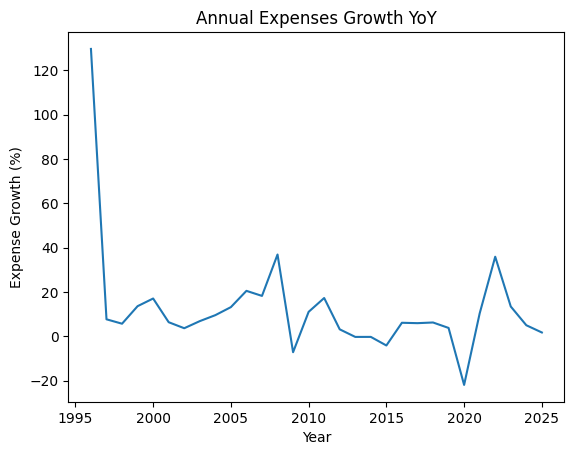

In [91]:
plt.plot(yoye.index,yoye.values)
plt.title('Annual Expenses Growth YoY')
plt.xlabel('Year')
plt.ylabel('Expense Growth (%)')
plt.show()

In [53]:
eff = yoyr - yoye

In [54]:
eff.head()

,Item_Value
Year,
1995,NaN
1996,-4.636757
1997,4.335033
1998,3.393151
1999,0.113674


In [57]:
eff.loc[2020]

np.float64(-37.73346874145871)

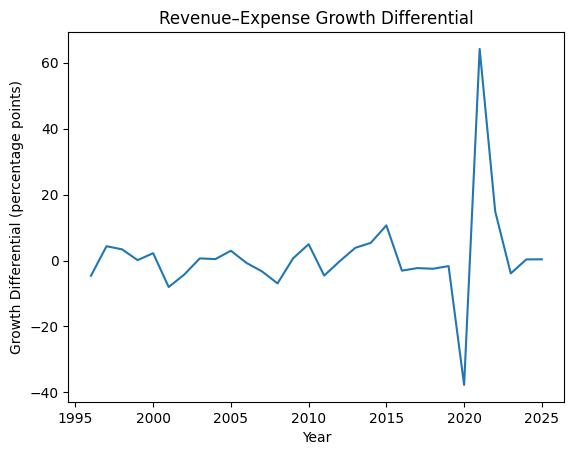

In [93]:
plt.plot(eff.index, eff.values)

plt.title('Revenue–Expense Growth Differential')
plt.xlabel('Year')
plt.ylabel('Growth Differential (percentage points)')

plt.show()

In [94]:
analysis_df = pd.DataFrame({
    'Revenue': rev,
    'Profit': profit,
    'Profit Margin': margin,
    'Revenue Growth': yoyr,
    'Expense Growth': yoye,
    'Revenue–Expense Growth Differential': eff
})

In [95]:
analysis_df.head()

,Revenue,Profit,Profit Margin,Revenue Growth,Expense Growth,Revenue–Expense Growth Differential
Year,,,,,,
1995,1.513999e+09,182821000.0,12.075371,NaN,NaN,NaN
1996,3.407361e+09,349728000.0,10.263896,125.057018,129.693775,-4.636757
1997,3.816997e+09,524322000.0,13.736505,12.022090,7.687057,4.335033
1998,4.164040e+09,683719000.0,16.419607,9.092043,5.698892,3.393151
1999,4.735648e+09,781531000.0,16.503148,13.727246,13.613572,0.113674


In [77]:
profit_change = analysis_df['Profit'].diff()

In [81]:
recovery = ((analysis_df.loc[2025, 'Revenue'] / analysis_df.loc[2020, 'Revenue']) - 1) * 100
recovery


np.float64(210.1501194565333)

In [92]:
analysis_df.loc[[2015, 2020]]

,Revenue,Profit,Profit Margin,Revenue Growth,Expense Growth,Growth Gap
Year,,,,,,
2015,1.982011e+10,4.116468e+09,20.769148,6.530430,-4.128134,10.658563
2020,9.048061e+09,-6.153893e+09,-68.013390,-59.656855,-21.923386,-37.733469


## 8. Key Findings

### Profitability

Southwest Airlines achieved its highest annual operating profit margin in 2015 at 20.77%. In 2015, revenue increased by 6.53%, while operating expenses decreased by 4.13%. This resulted in a positive revenue–expense growth differential of 10.66 percentage points. The weakest year was 2020, when operating profit fell to approximately −$6.15 billion and the operating profit margin reached −68.01%. In 2020, revenue declined by 59.66%, while expenses declined by only 21.92%, highlighting the impact of a large fall in revenue when costs cannot decline at the same rate.

### Recovery

Following the 2020 downturn, Southwest returned to positive operating profit in 2022. However, profitability remained well below the 2015 peak through 2025, despite revenue reaching approximately $28.06 billion in 2025. Although revenue recovered strongly after 2020, profitability recovered much more slowly, with the 2025 operating profit margin at approximately 1.53%, compared with 20.77% in 2015.

### Overall Insight

The analysis shows that revenue growth alone does not determine profitability. The relationship between revenue and operating expenses is also important. In 2015, revenue growth exceeded expense growth, coinciding with a strong operating margin. In contrast, 2020 shows how a sharp decline in revenue, combined with a smaller decline in expenses, coincided with significant operating losses.


## 9. Limitations

Limitations
The Southwest Airlines data in this analysis begins in Q3 1995, so 1995 does not represent a complete financial year.
Annual figures were calculated by aggregating quarterly observations, meaning the results depend on the availability and consistency of quarterly data.
The analysis focuses on operating revenue, operating expenses, and operating profit, rather than measures such as net income, cash flow, or share-price performance.
The revenue–expense growth differential used in this analysis is a custom analytical measure and is not a standard financial ratio.
The analysis identifies relationships and trends in the data but does not establish direct causation between changes in revenue, expenses, and profitability.

## 10.Data Source & Methodology

The data used in this project was obtained from the U.S. Department of Transportation's Bureau of Transportation Statistics (BTS). The dataset contains quarterly financial information for major U.S. airlines and is derived from Department of Transportation Form 41 reports.

For this analysis, the dataset was filtered to Southwest Airlines Co. and the quarterly observations from 1995 to 2025. The analysis focuses on operating revenue, operating expenses, and operating profit (loss). Annual values were calculated by aggregating the quarterly observations for each year. Operating profit margin and year-over-year revenue and expense growth were then calculated using Python and pandas. A revenue–expense growth differential was also calculated to compare changes in revenue with changes in operating expenses. The results were visualised using charts to identify trends in Southwest Airlines' financial performance over time.